# ILC method

After the first two steps:
1. Analythical work on g($\nu$),
2. Simultaions of mu-distorted tSZ + CMB + noise signals,

I will implement the ILC method.

This code must

1. Compute the correlation matrix: $$C_{ij} = \frac{1}{N_P} \Sigma_{p'} \left( d_i(p') \cdot d_j(p') \right)$$
(i.e. i,j = 1, ..., 20)

2. Invert the correlation matrix: $$\underline{\underline{C}} \rightarrow \underline{\underline{C^{-1}}}$$

3. Compute the weights: $$\underline{\omega} = \frac{\underline{\underline{C^{-1}}} \cdot \underline{g}}{\underline{g^\intercal} \cdot \underline{\underline{C^{-1}}} \cdot \underline{g}}$$

4. Apply the weights ($\omega_i$) to the data ($d_i$).

5. Get the output: $$\hat{y} = \Sigma_i \left( \omega_i \cdot d_i (p) \right)$$

### Previous

In [1]:
### IMPORT PACKAGES ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
import numba as nb
import matplotlib.pyplot as plt

import gc
from joblib import Parallel, delayed
from numba import njit, prange
from scipy.interpolate import *
from scipy import stats

from astropy.wcs import WCS
from reproject import reproject_from_healpix

import datetime

In [2]:
### MEMORY MANAGEMENT ###

import gc # Garbage Collector

# Before starting a new run, clear previous big variables if they exist
if 'data_cube' in locals():
    del data_cube
if 'alms_list' in locals():
    del alms_list
if 'y_hat_harmonic' in locals():
    del y_hat_harmonic
if 'y_hat_pixel' in locals():
    del y_hat_pixel

gc.collect() # Manually trigger memory cleanup

32

### Check frequencies and mu value!

In [3]:
### DEFINITIONS: CONSTANTS, FREQUENCIES, ETC. ###

# Nside
nside_work = 2048

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
planck_frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# Zegeye paper frequencies in GHz
zegeye_frequencies = [30, 40, 90, 150, 220, 270]

# Reference noise
base_sensitivity_uk_arcmin = 0.02

# Theoretical (LCDM) mu-distortion value
#mu = 2e-8
mu = 2e-4

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

print("------------ Configuration -------------")
print(f"Nside: {nside_work}")
print(f"Frequencies (GHz): {zegeye_frequencies}")
print(rf"T_CMB in muK: {T_cmb_muK:.1f} muK")
print(f"Theoretical mu-distortion value: {mu:.2e}")
print(f"Base sensitivity: {base_sensitivity_uk_arcmin} uK-arcmin")
print(f"Pixel area at Nside {nside_work}: {pixel_area_arcmin2:.2f} arcmin^2")
print("Date:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("----------------------------------------")

------------ Configuration -------------
Nside: 2048
Frequencies (GHz): [30, 40, 90, 150, 220, 270]
T_CMB in muK: 2725500.0 muK
Theoretical mu-distortion value: 2.00e-04
Base sensitivity: 0.02 uK-arcmin
Pixel area at Nside 2048: 2.95 arcmin^2
Date: 2026-04-29 11:16:18
----------------------------------------


### Pipeline

In [ ]:
### 1. Load the processed Maps and the data_cube ###

path_to_websky = '/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/'
#data_cube_name = "data_cube_6freq_no_y_0.02muK.fits"
data_cube_name = f"data_cube_{len(zegeye_frequencies)}freq_no_y_{base_sensitivity_uk_arcmin}muK.fits"
if not os.path.exists(path_to_websky + data_cube_name):
    print(f"Error: The file {data_cube_name} does not exist in the path {path_to_websky}. Please check the file name (and path).")

# A. Load the Data Cube (The 'Observed' (simulated) data)
data_cube = hp.read_map(path_to_websky + data_cube_name, field=None).astype(np.float32)
print(f"Loading the data_cube (3 layers: CMB + mu-distorted tSZ + noise) from file {data_cube_name}...")

# B. Load the Truth Maps (For validation and residuals)
y_map = hp.read_map(path_to_websky + "y_map.fits").astype(np.float32)
cmb_map = hp.read_map(path_to_websky + "cmb_map.fits").astype(np.float32)
print("Loading the original y_map and cmb_map for validation...")

print(f"Data Cube loaded. Shape: {data_cube.shape}")
print(f"{data_cube.shape[0]} frequencies: {zegeye_frequencies} with 3 layer maps of {data_cube.shape[1]} pixels as Nside = {nside_work}.")
# Should be (9, 50331648) for Nside 2048

Loading the muy_map, cmb_map and data_cube (3 layers: CMB + mu-distorted tSZ + noise) from file data_cube_6freq_no_y_0.02muK.fits...
Data Cube loaded. Shape: (6, 50331648)
6 frequencies: [30, 40, 90, 150, 220, 270] with 3 layer maps of 50331648 pixels as Nside = 2048.


In [5]:
### 2. Define the tSZ frequency scaling function g(nu) and Taylor expansion h(nu) ###

def get_physics_constants(nu):
    """Calculate the physics constants needed for tSZ scaling."""
    T_cmb = 2.7255     # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency
    return x

def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4
    return g_nu

def get_tsz_h(nu):
    """Calculate the tSZ Taylor expansion frequency scaling h(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    h_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    return h_nu

# ILC implementation

### Outline:

1. ILC method definition: Pixel ILC (P-ILC) & Harmonic ILC (H-ILC).


2. Processing for each signal:

| **Subsection** | __Signal__ | **SED** | **Extracted map** |
| :---: | :---: | :---: | :---: |
| 2.1. | $\mu$-distorted tSZ | $h(\nu) = - \frac{x}{2} \frac{1}{\sinh^2\left( \frac{x}{2} \right)}$ | $\mu y$-map |
| 2.2. | CMB | $a=[1,...,1]$ | $CMB$-map |

where $x \equiv \frac{h \nu}{k_B T_{CMB}}$.

3. Plotting two views for every map:
- Zoomed view.
- Mollweide view.

5. TT map: $\mu y$ Vs. $y$ for $\mu$ extraction.

## 1. ILC method definition

In [6]:
def run_pixel_ilc(data_cube, vector_muK): ### UNITLESS MAP OUTPUT + WEIGHTS ###

    # C definition
    n_freq, n_pix = data_cube.shape
    C = (1.0 / n_pix) * (data_cube @ data_cube.T) # IS IT THAT d_i (p') * d_j (p') = data_cube @ data_cube.T
    C_inv = np.linalg.pinv(C)

    # Calculate the weights
    weights = (C_inv @ vector_muK) / (vector_muK.T @ C_inv @ vector_muK)

    return weights @ data_cube, weights

# weights @ data_cube IS UNITLESS AS [weights] = 1/g^t * data_cube = 1/T_cmb * T_cmb
# [g] = T_cmb_muK
# [data_cube] = T_cmb_muK

In [45]:
def run_harmonic_ilc_with_weights(data_cube, vector_muK, l_bins): ### UNITLESS MAP OUTPUT + WEIGHTS PER BIN  ###
    """Advanced Harmonic-Space ILC (Multi-scale)"""
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    lmax = 3*nside-1
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    ell, _ = hp.Alm.getlm(lmax)
    
    # NEW: Matrix to store weights for each bin
    weights_per_bin = []

    for i in range(len(l_bins)-1):
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        inv_cov = np.linalg.pinv(cov_bin)
        
        # Calculate weights for THIS specific scale
        w_bin = (inv_cov @ vector_muK) / (vector_muK.T @ inv_cov @ vector_muK)
        weights_per_bin.append(w_bin) # Store them
        
        final_alms[mask] = w_bin @ bin_alms
        
    return hp.alm2map(final_alms, nside=nside), np.array(weights_per_bin)

## 2.1. $\mu$-distorted tSZ: $h(\nu) \rightarrow$ ($\mu y$-map)

In [7]:
### Define the h_vector_muK ###

# Define h_vector in muK units for the frequencies in the data cube
h_vector_muK = np.array([get_tsz_h(nu) for nu in zegeye_frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

In [8]:
### Check lengths of the vectors and frequencies ###

print(len(h_vector_muK))
print(len(zegeye_frequencies))

6
6


In [9]:
### See the h_vector values for the frequencies ### 

print(h_vector_muK/T_cmb_muK) # Should be unitless and match the expected h(nu) values for the frequencies

[-8.63164472e-01 -6.03276709e-01 -1.45132725e-01 -2.71060541e-02
 -3.34750331e-03 -7.05694421e-04]


In [ ]:
### P-ILC ON THE MU-DISTORTED tSZ SIGNAL ###

# Run P-ILC. The resulting map is unitless.
muy_hat_pixel, weights_pixel = run_pixel_ilc(data_cube, h_vector_muK)

muy_map = mu * y_map # The true mu-distorted tSZ signal in dimensionless units

# Calculate the residual in dimensionless mu*y units (Truth - Reconstruction)
muy_residual_pixel = muy_map - muy_hat_pixel

"""
# As y_map is also unitless, I will leave both unitless. However, I could also convert both to muK units and have a 10^5 scale factor.
muy_map_muK = muy_map * T_cmb_muK
residual_pixel_muK = muy_map_muK - muy_hat_pixel * T_cmb_muK
"""

# Validation: Both should be order 10^-13 (since mu is 10^-8 and y is 10^-5)
print(f"Truth max: {np.max(mu*y_map):.2e}")
print(f"Reco max: {np.max(muy_hat_pixel):.2e}")
print(f"Residual max: {np.max(muy_residual_pixel):.2e}")
print("WATCH!!! IS THERE A PROBLEM WITH RECO?")

Truth max: 3.99e-08
Reco max: 7.01e-08
Residual max: 6.85e-08
WATCH!!! THERE IS A PROBLEM WITH RECO...


In [12]:
### P-ILC WEIGHTS ANALYSIS ###

df_weights_pixel_ilc_muy = pd.DataFrame({
    'Freq (GHz)': zegeye_frequencies,
    'Weight': weights_pixel,
    'h(nu) * T_cmb_muK': h_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_ilc = df_weights_pixel_ilc_muy.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("--- P-ILC Analysis Weights ---")
print(df_horizontal_pixel_ilc)
print()

# Verify the constraint is satisfied
constraint_check_pixel_ilc = np.sum(weights_pixel * h_vector_muK)
weights_pixel_sum = np.sum(weights_pixel)
print(f"Constraint Check: {constraint_check_pixel_ilc:.4f}")
print(f"Sum of Weights: {weights_pixel_sum:.4f}")
#print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

--- P-ILC Analysis Weights ---
Freq (GHz)                  30            40            90            150           220           270
Weight            -4.287212e-07 -7.968508e-08  3.024549e-07  2.462852e-07  2.575737e-07 -2.979072e-07
h(nu) * T_cmb_muK -2.352555e+06 -1.644231e+06 -3.955592e+05 -7.387755e+04 -9.123620e+03 -1.923370e+03

Constraint Check: 1.0000
Sum of Weights: 0.0000


In [ ]:
### H-ILC ON THE MU-DISTORTED tSZ SIGNAL ###

# Extended range to capture high-resolution cluster details
l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

# Calculate the harmonic ILC reconstruction and get the weights for each bin
muy_hat_harmonic, weights_muy_harmonic_bins = run_harmonic_ilc_with_weights(data_cube, h_vector_muK * mu, l_bins)

# Residual map in mu*y units for harmonic ILC
muy_residual_harmonic = mu*y_map - muy_hat_harmonic

"""
Again, I could convert both to muK units and have a 10^5 scale factor, but I will leave them unitless for consistency with the pixel ILC.
muy_map_muK = muy_map * T_cmb_muK
muy_residual_harmonic = muy_map_muK - muy_hat_harmonic * T_cmb_muK
"""

# Validation: Both should be order 10^-13 (since mu is 10^-8 and y is 10^-5)
print(f"Truth max: {np.max(mu*y_map):.2e}")
print(f"Reco max: {np.max(muy_hat_harmonic):.2e}")
print(f"Residual max: {np.max(muy_residual_harmonic):.2e}")
print("WATCH!!! IS THERE A PROBLEM WITH RECO?")

Truth max: 3.99e-08
Reco max: 1.80e-04
Residual max: 1.24e-04


In [ ]:
### Define the g_vector_muK ###

# Define g_vector (and h_vector) in muK units for the frequencies in the data cube
g_vector_muK = np.array([get_tsz_g(nu) for nu in zegeye_frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

In [ ]:
### Check lengths of the vectors and frequencies ###

print(len(g_vector_muK)) # Should be 9, one for each frequency
print(len(zegeye_frequencies)) # Should be 9, one for each frequency

In [ ]:
### See the g_vector values for the frequencies ### 

print(g_vector_muK/T_cmb_muK) # Should be unitless and match the expected g(nu) values for the frequencies

## 3.1. P-ILC & H-ILC: $\mu y$-maps

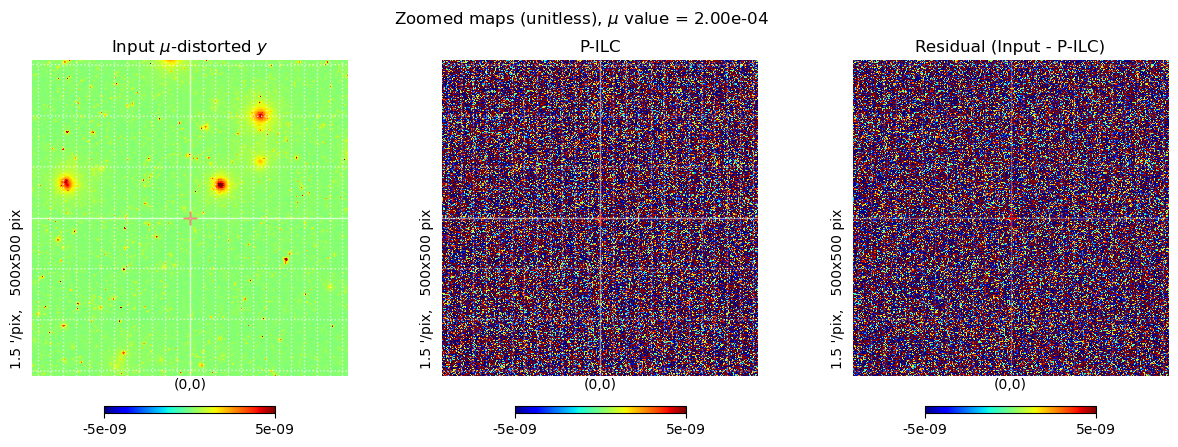

In [14]:
### A.1. PIXEL ILC ZOOMED MAPS ###

params_zoom_y = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_intermediate_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-9, 'max': 5*10**-9} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_zoom_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(muy_hat_pixel, title="P-ILC", **params_zoom_intermediate_muy)
#hp.gnomview(muy_hat_pixel, title="P-ILC", **params_zoom_y)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(muy_residual_pixel, title="Residual (Input - P-ILC)", **params_zoom_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle(rf"Zoomed maps (unitless), $\mu$ value = {mu:.2e}")
plt.savefig("Figures/ILC_no_y_0.02muK/mu_y_maps/P-ILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

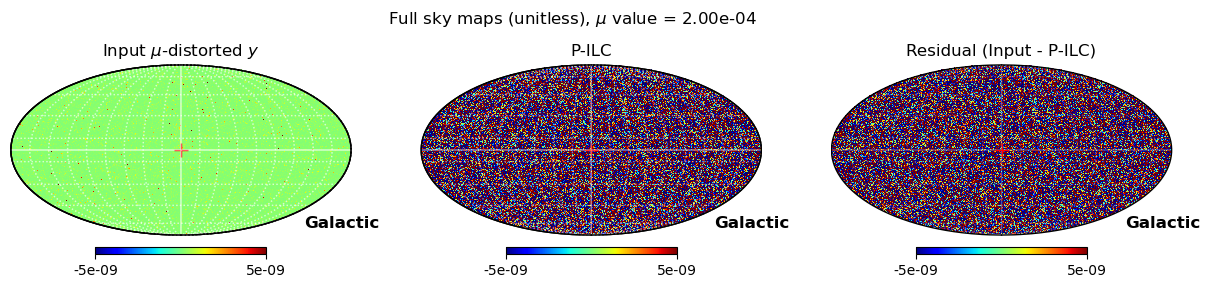

In [43]:
### A.2. PIXEL ILC FULL SKY MAPS ###

params_moll_y = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6}
params_moll_intermediate_muy = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-9, 'max': 5*10**-9}
params_moll_muy = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

ax1 = plt.subplot(1, 3, 1)
hp.mollview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_moll_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.mollview(muy_hat_pixel, title="P-ILC", **params_moll_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.mollview(muy_residual_pixel, title="Residual (Input - P-ILC)", **params_moll_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle(rf"Full sky maps (unitless), $\mu$ value = {mu:.2e}")
plt.savefig("Figures/ILC_no_y_0.02muK/mu_y_maps/P-ILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

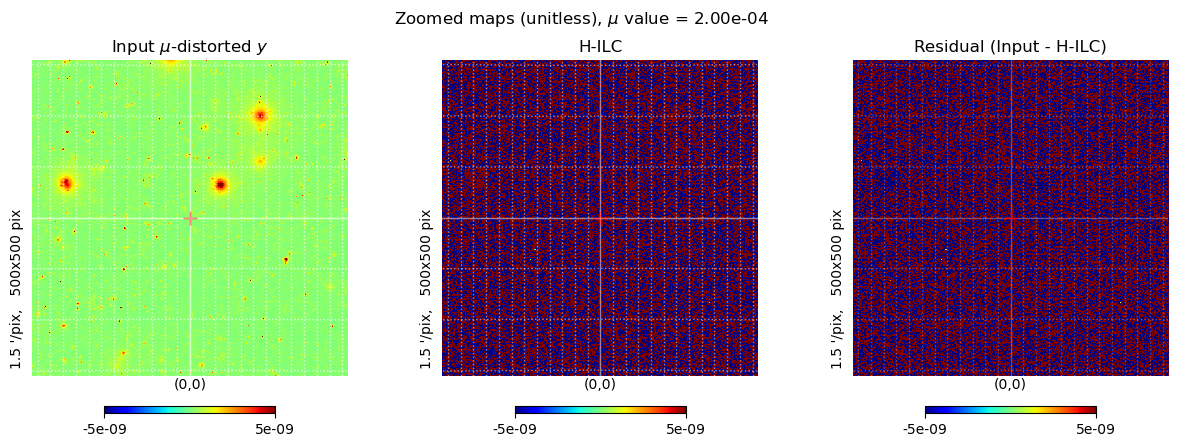

In [50]:
### B.1. HARMONIC ILC ZOOMED MAPS ###

params_zoom_y = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_intermediate_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-9, 'max': 5*10**-9} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 600, 'hold': True, 'cmap': 'jet', 'notext': False}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
hp.gnomview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_zoom_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 2)
hp.gnomview(muy_hat_harmonic, title="H-ILC", **params_zoom_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 3)
hp.gnomview(muy_residual_harmonic, title="Residual (Input - H-ILC)", **params_zoom_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle(rf"Zoomed maps (unitless), $\mu$ value = {mu:.2e}")
plt.savefig("Figures/ILC_no_y_0.02muK/mu_y_maps/H-ILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.2. HARMONIC ILC FULL SKY MAPS ###

params_moll_y = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6}
params_moll_intermediate_muy = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-9, 'max': 5*10**-9}
params_moll_muy = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

plt.subplot(1, 3, 1)
hp.mollview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_moll_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 2)
hp.mollview(muy_hat_harmonic, title="H-ILC", **params_moll_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 3)
hp.mollview(muy_residual_harmonic, title="Residual (Input - H-ILC)", **params_moll_intermediate_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle(rf"Full sky maps (unitless), $\mu$ value = {mu:.2e}")
plt.savefig("Figures/ILC_no_y_0.02muK/mu_y_maps/H-ILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.3. HARMONIC WEIGHTS EVOLUTION ###

plt.figure(figsize=(10, 6))

# Define labels for the x-axis bins
bin_labels = [f"{l_bins[i]}-{l_bins[i+1]}" for i in range(len(l_bins)-1)]

for f_idx, nu in enumerate(zegeye_frequencies):
    plt.plot(bin_labels, weights_muy_harmonic_bins[:, f_idx], label=f"{nu} GHz", marker='o', linewidth=2)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(rf"Multipole Scale ($\ell$ bin)")
plt.ylabel("H-ILC Weight")
plt.title(rf"Harmonic ILC weights evolution across scales, $\mu$ value = {mu:.2e}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("Figures/ILC_no_y_0.02muK/mu_y_maps/H-ILC_weights_evolution.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 2.2. CMB signal: $a = [1,...,1] \rightarrow$ ($CMB$-map)

In [ ]:
### P-ILC ON THE CMB COMPONENT ###
a_cmb_muK = np.ones(len(zegeye_frequencies)) * T_cmb_muK # CMB has the same amplitude in all frequencies, but we need to multiply by T_cmb_muK to have the correct units for the weights calculation, as the g_vector is in muK units. This way, the ILC will treat the CMB component with the correct scaling when calculating the weights.
signal_cmb = a_cmb_muK * cmb_map[:, np.newaxis]
# This will create a 2D array where each column is the CMB map (since a_cmb_muK is all ones, it just replicates the CMB map across all frequencies)

# Now we apply the ILC to the CMB signal alone to see if we can recover it
cmb_hat_pixel, weights_cmb = run_pixel_ilc(signal_cmb.T, a_cmb_muK) # We need to multiply a_cmb_muK by T_cmb_muK to have the correct units for the weights calculation

# Residual for the CMB reconstruction
cmb_residual_pixel = cmb_map - cmb_hat_pixel

In [ ]:
### H-ILC ON THE CMB COMPONENT ###
a_cmb_muK = np.ones(len(zegeye_frequencies)) * T_cmb_muK # CMB has the same amplitude in all frequencies, but we need to multiply by T_cmb_muK to have the correct units for the weights calculation, as the g_vector is in muK units. This way, the ILC will treat the CMB component with the correct scaling when calculating the weights.
signal_cmb = a_cmb_muK * cmb_map[:, np.newaxis]
# This will create a 2D array where each column is the CMB map (since a_cmb_muK is all ones, it just replicates the CMB map across all frequencies)

l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

# Now we apply the ILC to the CMB signal alone to see if we can recover it
cmb_hat_harmonic, weights_cmb = run_harmonic_ilc_with_weights(signal_cmb.T, a_cmb_muK, l_bins) # We need to multiply a_cmb_muK by T_cmb_muK to have the correct units for the weights calculation

# Residual for the CMB reconstruction
cmb_residual_harmonic = cmb_map - cmb_hat_harmonic

## 3.2. P-ILC & H-ILC: $CMB$-maps

In [ ]:
### A.1. P-ILC CMB ZOOMED MAPS ###

# Define units: use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

params_zoom_cmb = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -300, 'max': 300} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_cmb_residual = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -10, 'max': 10}
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(cmb_map, title="CMB input", unit=unit_label, **params_zoom_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(cmb_hat_pixel, title="P-ILC CMB Reconstruction", unit=unit_label, **params_zoom_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(cmb_residual_pixel, title="Residual (P-ILC - Input)", unit=unit_label, **params_zoom_cmb_residual)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/ILC_no_y_0.02muK/CMB_maps/P-ILC_CMB_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### A.2. P-ILC CMB FULL SKY MAPS ###

# Define units: use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

params_moll_cmb = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -300, 'max': 300}
params_moll_cmb_residual = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -10, 'max': 10}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

ax1 = plt.subplot(1, 3, 1)
hp.mollview(cmb_map, title="CMB input", unit=unit_label, **params_moll_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.mollview(cmb_hat_pixel, title="P-ILC CMB Reconstruction", unit=unit_label, **params_moll_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.mollview(cmb_residual_pixel, title="Residual (P-ILC - Input)", unit=unit_label, **params_moll_cmb_residual)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/ILC_no_y_0.02muK/CMB_maps/P-ILC_CMB_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.1. H-ILC CMB ZOOMED MAPS ###

# Define units: use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

params_zoom_cmb = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -300, 'max': 300} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_cmb_residual = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -10, 'max': 10}
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(cmb_map, title="CMB input", unit=unit_label, **params_zoom_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(cmb_hat_harmonic, title="H-ILC CMB Reconstruction", unit=unit_label, **params_zoom_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(cmb_residual_harmonic, title="Residual (H-ILC - Input)", unit=unit_label, **params_zoom_cmb_residual)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/ILC_no_y_0.02muK/CMB_maps/H-ILC_CMB_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.2. H-ILC CMB FULL SKY MAPS ###

params_moll_cmb = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -300, 'max': 300}
params_moll_cmb_residual = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -10, 'max': 10}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

ax1 = plt.subplot(1, 3, 1)
hp.mollview(cmb_map, title="CMB input", unit=unit_label, **params_moll_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.mollview(cmb_hat_harmonic, title="H-ILC CMB Reconstruction", unit=unit_label, **params_moll_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.mollview(cmb_residual_harmonic, title="Residual (H-ILC - Input)", unit=unit_label, **params_moll_cmb_residual)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/ILC_no_y_0.02muK/CMB_maps/H-ILC_CMB_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 5. T-T plot: $\mu y$ Vs. $y$ for $\mu$ extraction

### 5.1. Calculating cluster galactic coordinates: (l,b)

In [32]:
n_clusters = 1000

In [ ]:
def get_brightest_cluster_coords(y_map, n_clusters, min_dist_deg=1.0):
    """Finds the coordinates of the n brightest clusters."""
    # Create a copy to avoid modifying original
    temp_map = np.copy(y_map)
    nside = hp.npix2nside(len(temp_map))
    coords = []
    
    for i in range(n_clusters):
        # Find pixel with maximum value
        pix_max = np.argmax(temp_map)
        
        # Convert to Galactic coordinates
        theta, phi = hp.pix2ang(nside, pix_max)
        lon = np.degrees(phi)
        lat = 90 - np.degrees(theta)
        coords.append((lon, lat))
        
        # Zero out the surrounding area so we don't pick the same cluster
        # A 1-degree radius is usually enough for WebSky clusters
        vec = hp.pix2vec(nside, pix_max)
        disc_pix = hp.query_disc(nside, vec, radius=np.radians(min_dist_deg))
        temp_map[disc_pix] = 0
        
    return coords

In [21]:
### EXTRACTING THE COORDINATES OF THE BRIGHTEST CLUSTERS ###
cluster_coords = get_brightest_cluster_coords(muy_map)
print("Coordinates of the 1000 brightest clusters.")
print("Only the first 10 are shown for brevity (lon, lat) in degrees):")
for i, (lon, lat) in enumerate(cluster_coords[:10]):  # Print only the first 10 for brevity
    print(f"{i+1}: (lon: {lon:.2f}, lat: {lat:.2f})")

Coordinates of the 1000 brightest clusters.
Only the first 10 are shown for brevity (lon, lat) in degrees):
1: (lon: 33.25, lat: -42.09)
2: (lon: 267.82, lat: -11.49)
3: (lon: 115.58, lat: -7.54)
4: (lon: 281.82, lat: -13.77)
5: (lon: 105.11, lat: 57.23)
6: (lon: 207.55, lat: 14.38)
7: (lon: 262.53, lat: 16.78)
8: (lon: 318.82, lat: -6.56)
9: (lon: 88.10, lat: 51.88)
10: (lon: 146.18, lat: -14.09)


### 5.2. Stacking clusters from $y$ and $\mu y$ maps

In [22]:
def stack_clusters(hp_map, coords, reso_arcmin=1.5, xsize=100):
    """Stacks small patches around specified coordinates."""
    stacked_patch = np.zeros((xsize, xsize))
    
    for lon, lat in coords:
        # Project a small area into a flat 2D patch
        patch = hp.gnomview(hp_map, rot=[lon, lat], reso=reso_arcmin, 
                            xsize=xsize, return_projected_map=True, no_plot=True)
        stacked_patch += patch
        
    return stacked_patch / len(coords)

In [23]:
### STACKING THE REAL SIGNALS AROUND THE BRIGHTEST CLUSTERS - test on the stacking method ###

y_map = y_map # The true tSZ signal in dimensionless units
muy_map = mu * y_map # The true mu-distorted tSZ signal in dimensionless units

# Use the truth maps first to verify the method)
stack_y_real = stack_clusters(y_map, cluster_coords)
stack_muy_real = stack_clusters(muy_map, cluster_coords)

In [24]:
### STACKING THE PILC SIGNALS AROUND THE BRIGHTEST CLUSTERS ###

# Extract stacked signals from your PILC reconstructions
stack_muy_pixel = stack_clusters(muy_hat_pixel, cluster_coords)

In [51]:
### STACKING THE HILC SIGNALS AROUND THE BRIGHTEST CLUSTERS ###

# Extract stacked signals from your HILC reconstructions
stack_muy_harmonic = stack_clusters(muy_hat_harmonic, cluster_coords)

### 5.3. Plotting the stacked clusters

In [26]:
def plot_stacked_patches(stacked_map, n_clusters, filename):
    """
    Plots the average (stacked) patches for the only signal.
    """

    fig = plt.figure(figsize=(6, 5))
    plt.imshow(stacked_map, origin='lower', cmap='jet', extent=[-stacked_map.shape[0]//2, stacked_map.shape[0]//2, -stacked_map.shape[1]//2, stacked_map.shape[1]//2])
    plt.colorbar(label='Average Signal (unitless)')
    plt.title(f'Stacked Patch of {n_clusters} Brightest Clusters')
    plt.xlabel('Pixels')
    plt.ylabel('Pixels')
    plt.savefig(f"Figures/ILC_no_y_0.02muK/mu_y_maps/Stacking/{filename}", dpi=300, bbox_inches='tight')
    plt.show()

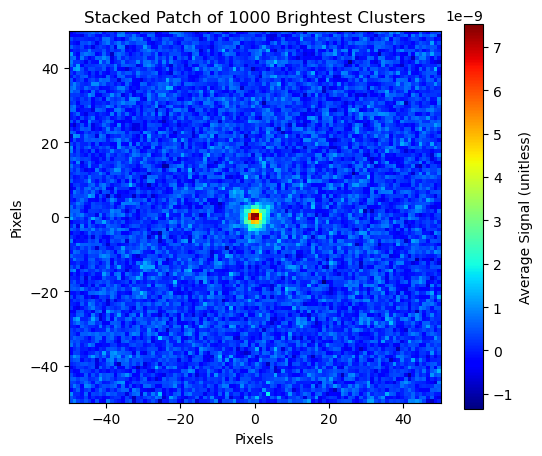

In [33]:
### PLOTING THE PILC STACKED PATCHES ###

plot_stacked_patches(stack_muy_pixel, n_clusters, filename="Stacked_Patches_PILC_no_y.pdf")

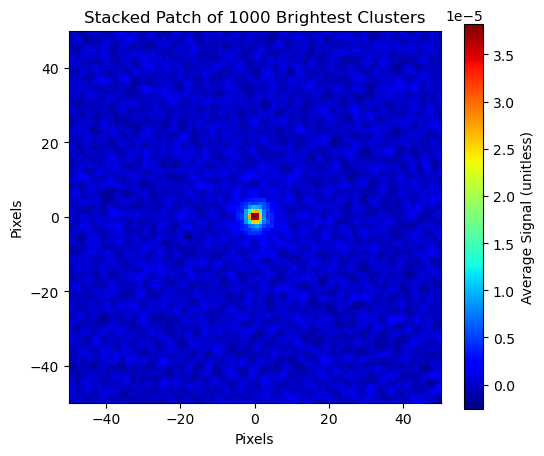

In [52]:
### PLOTING THE HILC STACKED PATCHES ###

plot_stacked_patches(stack_muy_harmonic, n_clusters, filename="Stacked_Patches_HILC_no_y.pdf")

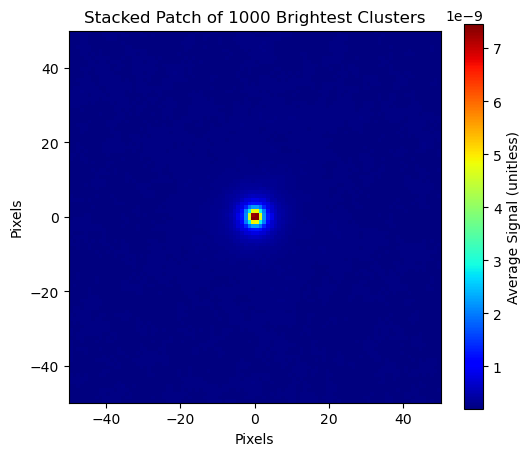

In [34]:
### PLOTING THE STACKED PATCHES OF THE REAL DATA ###

plot_stacked_patches(stack_muy_real, n_clusters, filename="Stacked_Patches_Real_Data_no_y.pdf")

### 5.4. Temperature-Temperature plot: $\mu y$ Vs. $y$ and linear regression - the slope represents $\mu$

In [35]:
def plot_y_vs_muy(stack_y, stack_muy,
                        filename="TT_Plot.pdf",
                        xlabel=rf'Stacked $y$ real signal (unitless)',
                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                        title=rf'T-T Plot: processed $\mu y$ Vs. real $y$'):
    
    # Flatten the 2D patches into 1D arrays for regression
    x_data = stack_y.flatten()
    y_data = stack_muy.flatten()
    
    # Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels')
    
    # Plot the regression line
    line = slope * x_data + intercept
    #plt.plot(x_data, line, color='red', label=f'Fit: slope={slope:.2e}')
    plt.plot(x_data, line, color='red', label=rf'$\mu$ = {slope:.2e}')

    # Limit the axes to focus on the cluster signal range
    #plt.xlim(0, 1e-5)
    #plt.ylim(0, 1e-5)

    #plt.xlabel(rf'Stacked $y$ real signal')
    #plt.ylabel(rf'Stacked $\mu y$ processed signal')
    #plt.title(rf'T-T Plot: $\mu y$ Vs. real $y$')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Figures/ILC_no_y_0.02muK/mu_y_maps/TT_plots/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

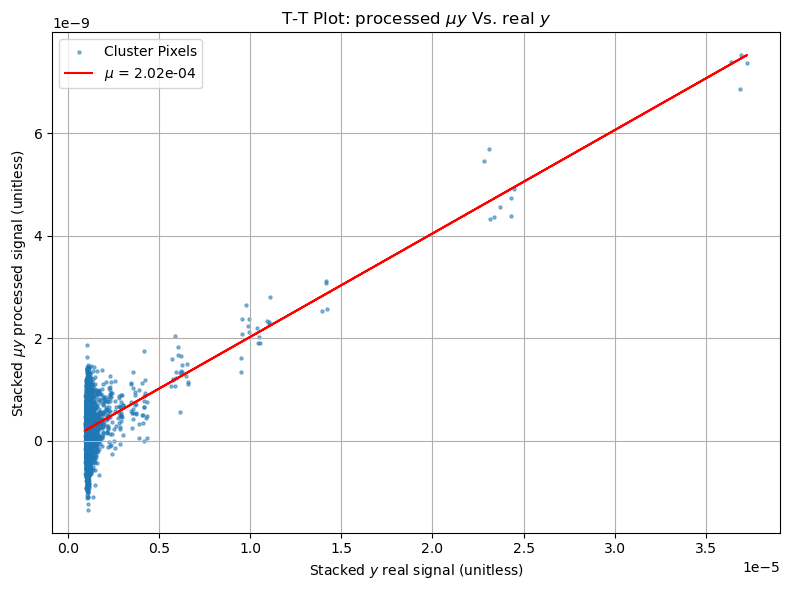

--- Statistics ---
y = 2.02e-04 * x + 4.08e-12
R-squared: 0.2493, p-value: 0.00e+00, std_err: 3.51e-06
----------------------
Measured mu = 2.02e-04
Input    mu = 2.00e-04


In [36]:
### PLOTTING THE PILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_real Vs. muy_hat ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy(stack_y_real, stack_muy_pixel,
                                                                        filename="TT_Plot_PILC_no_y.pdf",
                                                                        xlabel=rf'Stacked $y$ real signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = 2.00e-04")

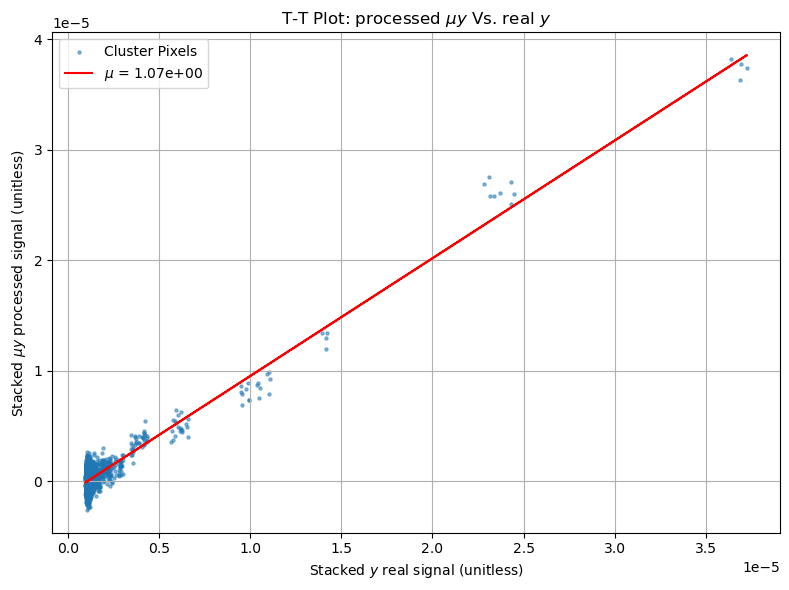

--- Statistics ---
y = 1.07e+00 * x + -1.15e-06
R-squared: 0.7456, p-value: 0.00e+00, std_err: 6.23e-03
----------------------
Measured mu = 1.07e+00
Input    mu = 2.00e-04


In [53]:
### PLOTTING THE HILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_real Vs. muy_hat ###

measured_mu, intercept, r_value, p_value, std_err = plot_y_vs_muy(stack_y_real, stack_muy_harmonic,
                                                                        filename="TT_Plot_HILC_no_y.pdf",
                                                                        xlabel=rf'Stacked $y$ real signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = 2.00e-04")

### Should I use the absolute value?

### Check whether we have a 1:1 correlation slope or not for this "y-free" data set

In [55]:
def plot_real_muy_vs_muy(stack_real_muy, stack_muy,
                        filename="TT_Plot.pdf",
                        xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                        title=rf'T-T Plot: processed $\mu y$ Vs. real $\mu y$'):
    
    # Flatten the 2D patches into 1D arrays for regression
    x_data = stack_real_muy.flatten()
    y_data = stack_muy.flatten()
    
    # Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels')
    
    # Plot the regression line
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', label=f'slope={slope:.2e}')

    # Limit the axes to focus on the cluster signal range
    #plt.xlim(-1e-8, 1e-8)
    #plt.ylim(-1e-8, 1e-8)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Figures/ILC_no_y_0.02muK/mu_y_maps/TT_plots/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

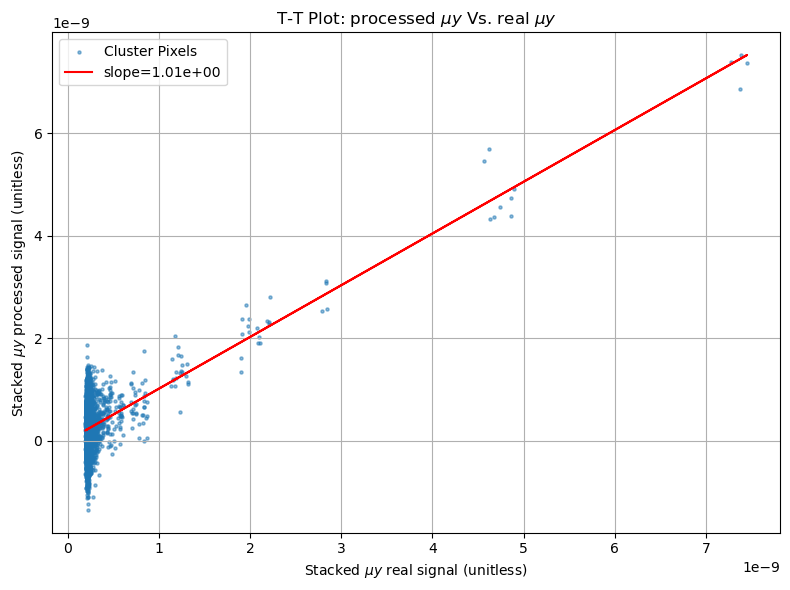

--- Statistics ---
y = 1.01e+00 * x + 4.08e-12
R-squared: 0.2493, p-value: 0.00e+00, std_err: 1.75e-02
----------------------
Slope = 1.01e+00
Input mu = 2.00e-04


In [56]:
### PLOTTING THE PILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- muy_real Vs. muy_hat ###

measured_mu, intercept, r_value, p_value, std_err = plot_real_muy_vs_muy(stack_muy_real, stack_muy_pixel,
                                                                        filename="TT_Plot_PILC_no_y_muy_muy.pdf",
                                                                        xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $\mu y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Slope = {measured_mu:.2e}")
print(f"Input mu = 2.00e-04")

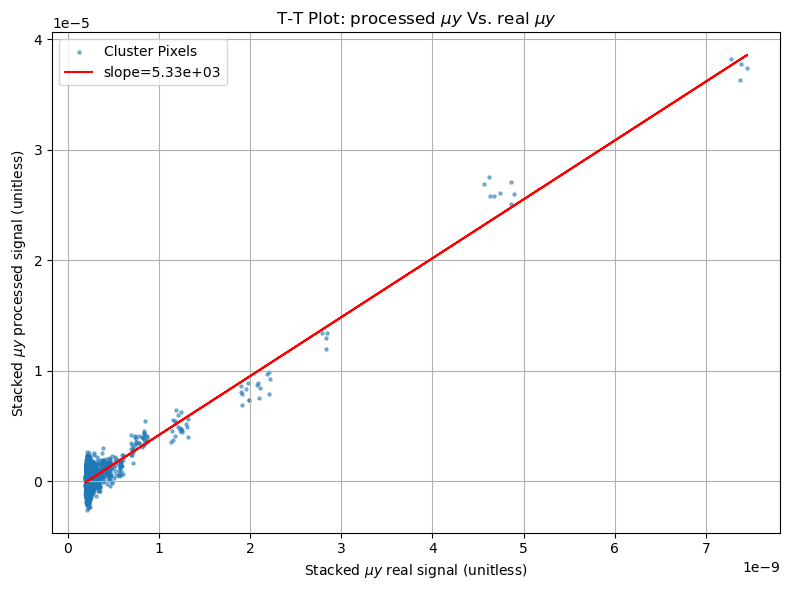

--- Statistics ---
y = 5.33e+03 * x + -1.15e-06
R-squared: 0.7456, p-value: 0.00e+00, std_err: 3.11e+01
----------------------
Slope = 5.33e+03
Input mu = 2.00e-04


In [57]:
### PLOTTING THE HILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- muy_real Vs. muy_hat ###

measured_mu, intercept, r_value, p_value, std_err = plot_real_muy_vs_muy(stack_muy_real, stack_muy_harmonic,
                                                                        filename="TT_Plot_HILC_no_y_muy_muy.pdf",
                                                                        xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $\mu y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Slope = {measured_mu:.2e}")
print(f"Input mu = 2.00e-04")

In [40]:
print(mu)

0.0002


### Weighted Linear Regressions (WLS)

In [ ]:
def plot_y_vs_muy_wls(stack_y, stack_muy,
                        filename="TT_Plot_Weighted.pdf",
                        xlabel=rf'Stacked $y$ real signal (unitless)',
                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                        title=rf'Weighted T-T Plot: processed $\mu y$ Vs. real $y$'):
    
    # Flatten the 2D patches into 1D arrays for regression
    x_data = stack_y.flatten()
    y_data = stack_muy.flatten()
    
    # Define Weights: Give more importance to high-signal pixels
    # Using the square of the truth signal is a standard way to mitigate attenuation bias
    weights = np.abs(x_data)**2 
    
    # Weighted Linear Regression using numpy.polyfit
    # w=np.sqrt(weights) because polyfit minimizes sum(w^2 * error^2)
    slope, intercept = np.polyfit(x_data, y_data, 1, w=np.sqrt(weights))
    
    # Recalculate R-squared for the weighted fit
    y_pred = slope * x_data + intercept
    weighted_mean_y = np.sum(weights * y_data) / np.sum(weights)
    ss_res = np.sum(weights * (y_data - y_pred)**2)
    ss_tot = np.sum(weights * (y_data - weighted_mean_y)**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.3, s=5, label='Cluster Pixels', color='gray')
    
    # Plot the regression line
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', lw=2, label=rf'Weighted Fit ($\mu$ = {slope:.2e})')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"Figures/ILC_no_y_2muK/mu_y_maps/TT_plots/WLS/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_squared

In [ ]:
### PLOTTING THE PILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_real Vs. muy_hat_pixel ###

measured_mu, intercept, r_squared = plot_y_vs_muy_wls(stack_y_real, stack_muy_pixel,
                                                        filename="TT_Plot_PILC_no_y_wls.pdf",
                                                        xlabel=rf'Stacked $y$ real signal (unitless)',
                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_squared:.4f}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = 2.00e-04")

In [ ]:
### PLOTTING THE HILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_real Vs. muy_hat_harmonic ###

measured_mu, intercept, r_squared = plot_y_vs_muy_wls(stack_y_real, stack_muy_harmonic,
                                                        filename="TT_Plot_HILC_no_y_wls.pdf",
                                                        xlabel=rf'Stacked $y$ real signal (unitless)',
                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_squared:.4f}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = 2.00e-04")

In [ ]:
def plot_real_muy_vs_muy_wls(stack_real_muy, stack_muy,
                        filename="TT_Plot_Gain_Weighted.pdf",
                        xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                        title=rf'Weighted T-T Plot: processed $\mu y$ Vs. real $\mu y$'):
    
    # Flatten the 2D patches into 1D arrays for regression
    x_data = stack_real_muy.flatten()
    y_data = stack_muy.flatten()
    
    # Define Weights: Highlight the peak of the mu*y signal
    weights = np.abs(x_data)**2 
    
    # Weighted Linear Regression
    slope, intercept = np.polyfit(x_data, y_data, 1, w=np.sqrt(weights))
    
    # Recalculate R-squared
    y_pred = slope * x_data + intercept
    weighted_mean_y = np.sum(weights * y_data) / np.sum(weights)
    ss_res = np.sum(weights * (y_data - y_pred)**2)
    ss_tot = np.sum(weights * (y_data - weighted_mean_y)**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.3, s=5, label='Cluster Pixels', color='gray')
    
    # Plot the regression line
    line = slope * x_data + intercept
    plt.plot(x_data, line, color='red', lw=2, label=rf'Weighted slope = {slope:.2f}')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"Figures/ILC_no_y_2muK/mu_y_maps/TT_plots/WLS/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_squared

In [ ]:
### PLOTTING THE PILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- muy_real Vs. muy_hat_pixel ###

measured_mu, intercept, r_squared = plot_real_muy_vs_muy_wls(stack_muy_real, stack_muy_pixel,
                                                                        filename="TT_Plot_PILC_no_y_muy_muy_wls.pdf",
                                                                        xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $\mu y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_squared:.4f}")
print("----------------------")
print(f"Slope = {measured_mu:.2e}")
print(f"Input mu = 2.00e-04")

In [ ]:
### PLOTTING THE HILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- muy_real Vs. muy_hat_harmonic ###

measured_mu, intercept, r_squared = plot_real_muy_vs_muy_wls(stack_muy_real, stack_muy_harmonic,
                                                                        filename="TT_Plot_HILC_no_y_muy_muy_wls.pdf",
                                                                        xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $\mu y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_squared:.4f}")
print("----------------------")
print(f"Slope = {measured_mu:.2e}")
print(f"Input mu = 2.00e-04")

### Signal-masking

In [ ]:
def plot_y_vs_muy_sm(stack_y, stack_muy, 
                  filename="TT_Plot_Refined.pdf",
                  xlabel=rf'Stacked $y$ real signal (unitless)',
                  ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                  title=rf'T-T Plot: processed $\mu y$ Vs. real $y$'):
    
    # Flatten the 2D patches
    x_data = stack_y.flatten()
    y_data = stack_muy.flatten()
    
    # REFINED STRATEGY: Filter for signal
    # We only fit the line to pixels where the real signal is above a noise threshold
    # This prevents the "noise cloud" at (0,0) from flattening the slope (Attenuation Bias)
    mask = x_data > (np.max(x_data) * 0.1) # Use top 90% of signal pixels
    x_fit = x_data[mask]
    y_fit = y_data[mask]
    
    # Perform standard linear regression on the filtered signal
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)
    
    # Plotting all data points
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.2, s=5, label='All Pixels', color='gray')
    plt.scatter(x_fit, y_fit, alpha=0.5, s=5, label='Signal Pixels Used for Fit', color='blue')
    
    # Plot the regression line across the full range
    line_x = np.array([np.min(x_data), np.max(x_data)])
    line_y = slope * line_x + intercept
    plt.plot(line_x, line_y, color='red', lw=2, label=rf'Refined Fit ($\mu$ = {slope:.2e})')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"Figures/ILC_no_y_2muK/mu_y_maps/TT_plots/Signal Masking/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value**2

In [ ]:
### PLOTTING THE PILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_real Vs. muy_hat_pixel ###

measured_mu, intercept, r_squared = plot_y_vs_muy_sm(stack_y_real, stack_muy_pixel,
                                                        filename="TT_Plot_PILC_no_y_sm.pdf",
                                                        xlabel=rf'Stacked $y$ real signal (unitless)',
                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_squared:.4f}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = 2.00e-04")

In [ ]:
### PLOTTING THE HILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- y_real Vs. muy_hat_harmonic ###

measured_mu, intercept, r_squared = plot_y_vs_muy_sm(stack_y_real, stack_muy_harmonic,
                                                        filename="TT_Plot_HILC_no_y_sm.pdf",
                                                        xlabel=rf'Stacked $y$ real signal (unitless)',
                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_squared:.4f}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = 2.00e-04")

In [ ]:
def plot_real_muy_vs_muy_sm(stack_real_muy, stack_muy, 
                         filename="TT_Plot_Gain_Refined.pdf",
                         xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                         ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                         title=rf'T-T Plot: processed $\mu y$ Vs. real $\mu y$'):
    
    x_data = stack_real_muy.flatten()
    y_data = stack_muy.flatten()
    
    # Filter for signal pixels in the mu*y truth map
    mask = x_data > (np.max(x_data) * 0.1)
    x_fit = x_data[mask]
    y_fit = y_data[mask]
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.2, s=5, label='All Pixels', color='gray')
    plt.scatter(x_fit, y_fit, alpha=0.5, s=5, label='Signal Pixels Used for Fit', color='green')
    
    line_x = np.array([np.min(x_data), np.max(x_data)])
    line_y = slope * line_x + intercept
    plt.plot(line_x, line_y, color='red', lw=2, label=rf'Refined Gain = {slope:.2f}')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"Figures/ILC_no_y_2muK/mu_y_maps/TT_plots/Signal Masking/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value**2

In [ ]:
### PLOTTING THE PILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- muy_real Vs. muy_hat_pixel ###

measured_mu, intercept, r_squared = plot_real_muy_vs_muy_sm(stack_muy_real, stack_muy_pixel,
                                                                        filename="TT_Plot_PILC_no_y_muy_muy_sm.pdf",
                                                                        xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $\mu y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_squared:.4f}")
print("----------------------")
print(f"Slope = {measured_mu:.2e}")
print(f"Input mu = 2.00e-04")

In [ ]:
### PLOTTING THE HILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE --- muy_real Vs. muy_hat_harmonic ###

measured_mu, intercept, r_squared = plot_real_muy_vs_muy_sm(stack_muy_real, stack_muy_harmonic,
                                                                        filename="TT_Plot_HILC_no_y_muy_muy_sm.pdf",
                                                                        xlabel=rf'Stacked $\mu y$ real signal (unitless)',
                                                                        ylabel=rf'Stacked $\mu y$ processed signal (unitless)',
                                                                        title=rf'T-T Plot: processed $\mu y$ Vs. real $\mu y$')
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_squared:.4f}")
print("----------------------")
print(f"Slope = {measured_mu:.2e}")
print(f"Input mu = 2.00e-04")